# Equations non-linéaires

### Méthode de la bissection 

On s'intéresse ici à la résolution de l'équation $f(x) = 0$, où $f:[a,b] \subset \mathbb{R} \to \mathbb{R}$ 
une fonction continue telle que $f(a)f(b) <0$, avec la méthode de la bissection, dont l'algorithme est le suivant : 

1. Soient 
   $f$ une fonction, 
   [a,b] un intervalle où $f$ présente un changement de signe, 
    $\epsilon$ une tolérance, 
   $N$ un nombre maximal d'itérations.

2. Initialisation $k=0$, $err=\frac{b-a}2$ (compteur d'itérations et borne erreur)

3. tant que le critère d'arrêt n'est pas verifié, faire :
   
   $\quad x_m = \displaystyle\frac{a+b}{2}$ (calcul du point milieu)
   
   $\quad\mbox{Si $f(x_m) = 0$ alors términer}$
       
   $\quad\mbox{si $f(a)f(x_m) < 0$ alors  $b = x_m$}$
      
   $\quad\mbox{si $f(x_m)f(b) < 0$ alors $a = x_m$}$
   
   $\quad\mbox{$k \leftarrow k+1$, $err =\displaystyle\frac{b-a}2$}$ 
   
   fin (tant que)

4. retourner (ou afficher) $x_m$, $f(x_m)$, $err$ et $k$


Le critère d'arrêt est $err < \epsilon $ ou $k > N$. 

## Exercice 1

a) Compléter le programme ci-dessous. 


In [15]:
def bissection(f, a, b, tol, N):
    k = 0                 # initialisation compteur
    err = (b-a)*0.5       # initialisation borne erreur
    if f(a)*f(b) > 0:
        print("Problème : f ne change pas de signe dans l'intervalle [a,b]")    
        return 0
    while err >= tol and k <= N: 
        xm = (a+b)*0.5
        print("a = ",a," b = ",b)
        if f(xm) == 0.0:
            print("Solution trouvée, itération k = ", k)
            break
        if f(xm)*f(a) < 0:
            b = xm
        if f(xm)*f(b) < 0:
            a = xm
        k=k+1
        err = (b-a)*0.5
        print(xm,err, f(xm))
    if k > N:
        print("nombre maximal d'itérations atteint : pas de convergence")
    return [xm,f(xm),err,k]

# fin fonction bissection 

b) Tester la fonction bissection 
avec la fonction  $x\mapsto f(x) = x^2-2$, puis à la fonction $x\mapsto f(x) = \cos(x) - x$, avec des valeurs différentes de $a$, $b$, et $\epsilon$.

In [16]:
import math as m
import numpy as np

def f1(x):
    return x**2 - 2.

def f2(x):
    return np.cos(x) - x

def f3(x):
    return 2.*x**3 + x -2. 

def f4(x):
    return -0.9*x**2 + 1.7*x +2.5 

bissection(f4,2.8,3.0,1e-12,6)

a =  2.8  b =  3.0
2.9 0.050000000000000044 -0.13900000000000023
a =  2.8  b =  2.9
2.8499999999999996 0.025000000000000133 0.03474999999999984
a =  2.8499999999999996  b =  2.9
2.875 0.012500000000000178 -0.05156250000000018
a =  2.8499999999999996  b =  2.875
2.8625 0.006250000000000089 -0.008265624999999943
a =  2.8499999999999996  b =  2.8625
2.8562499999999997 0.0031250000000000444 0.013277343750000448
a =  2.8562499999999997  b =  2.8625
2.859375 0.0015624999999999112 0.002514648437498934
a =  2.859375  b =  2.8625
2.8609375 0.0007812499999999556 -0.002873291015625945
nombre maximal d'itérations atteint : pas de convergence


[2.8609375, -0.002873291015625945, 0.0007812499999999556, 7]

c) On veut étudier la vitesse de convergence de la méthode de bissection. 
    
Soit  l'équation non-linéaire $e^x - 2 =0$.  Modifier la fonction "bissection" afin qu'elle 
retourne un tableau avec tous 
les termes $x_m$ (les points milieux calculés à chaque itération). 

Calculer ensuite un tableau avec les erreurs 

$\quad e_k = |x_k - x^*|, \quad k\geq 0,$


où $x^*$ est la solution ''exacte'' de $e^x - 2 =0$. Tracer $\log(e_k)$ en fonction de $k$. Interpréter.  

Indication. Pour garder les valeurs des points milieux dans un tableau on pourrait 

a) Soit utiliser une liste de python. 
Par exemple, on peut créer une liste vide  avec x=[]. A chaque itération on ajoute le terme xm à la liste avec x.append(xm). Enfin on transforme la liste en array avec xa = numpy.array(x) (pour pouvoir faire des calculs vectoriels).

b) Soit utiliser un array de numpy. Par exemple on peut créer  un array initial rempli de $N$  zeros avec xk = numpy.zeros(N) ($N$ c'est le nombre maximal d'itérations) et à chaque itération on ajoute le terme xm avec xk[k] = xm. Avec cette méthode, si l'algortihme converge avant le nombre maximal d'itérations, il faudrait éliminer les valeurs nuls de l'array  en faisant, par exemple, xk = xk[range(K)] où K est le nombre d'itérations effectuées. Pour connaître la taille du tableau on pourrait utiliser xk.size.


0.5 0.25
0.75 0.125
0.625 0.0625
0.6875 0.03125
0.71875 0.015625
0.703125 0.0078125
0.6953125 0.00390625
0.69140625 0.001953125
0.693359375 0.0009765625
0.6923828125 0.00048828125
0.69287109375 0.000244140625
0.693115234375 0.0001220703125
0.6932373046875 6.103515625e-05
0.69317626953125 3.0517578125e-05
0.693145751953125 1.52587890625e-05
0.6931610107421875 7.62939453125e-06
0.6931533813476562 3.814697265625e-06
0.6931495666503906 1.9073486328125e-06
0.6931476593017578 9.5367431640625e-07
0.6931467056274414 4.76837158203125e-07
0.6931471824645996 2.384185791015625e-07
0.6931469440460205 1.1920928955078125e-07
0.6931470632553101 5.960464477539063e-08
0.6931471228599548 2.9802322387695312e-08
0.6931471526622772 1.4901161193847656e-08
0.6931471675634384 7.450580596923828e-09
itérés =  [0.5        0.75       0.625      0.6875     0.71875    0.703125
 0.6953125  0.69140625 0.69335938 0.69238281 0.69287109 0.69311523
 0.6932373  0.69317627 0.69314575 0.69316101 0.69315338 0.69314957
 0.6931

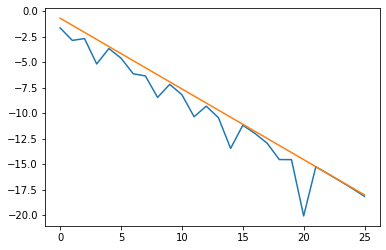

In [9]:
import numpy as np
import matplotlib.pyplot as plt
def bissection2(f, a, b, tol, N):
    k = 0                 # initialisation compteur
    err = (b-a)*0.5       # initialisation borne erreur
    xk = np.zeros(N);     # initialisation array numpy pour garder les points milieux
    while err > tol and k <= N : 
        xm = (a+b)*0.5
        xk[k]=xm
        if f(xm) == 0.0:
            print("Solution trouvée, itération k = ", k)
            break
        if f(xm)*f(a) < 0:
            b = xm
        if f(xm)*f(b) < 0:
            a = xm
        k=k+1
        err = (b-a)*0.5
        print(xm,err)
    if k > N:
        print("nombre maximal d'itérations atteint : pas de convergence") 
    xk = xk[range(k)]
    return xk 

def f3(x):
    return np.exp(x)-2.

xex = np.log(2)
xk = bissection2(f3,0,1,1.e-8,100)
print("itérés = ", xk)
ek = abs(xk -xex)
print("erreur = ", ek)
k=range(xk.size)
k=np.array(k)
plt.plot(np.log(ek))
bel = (k+1)*np.log(0.5)
print("log borne erreur = ", bel)
plt.plot(bel)

### Méthode de la fausse position

On s'intéresse toujours à la résolution de l'équation $f(x) = 0$, où $f:[a,b] \subset \mathbb{R} \to \mathbb{R}$ 
une fonction continue telle que $f(a)f(b) <0$. Une version de l'algorithme de la méthode de la fausse position est la suivante : 

1. Soient 
   $f$ une fonction, 
   [a,b] un intervalle où $f$ présente un changement de signe, 
    $\epsilon$ une tolérance, 
   $N$ un nombre maximal d'itérations.

2. Initialisation $k=0$, $err={|b-a|}$ (compteur d'itérations et borne erreur)

3. tant que le critère d'arrêt n'est pas verifié, faire :
   
   $\quad y_2 = f(a)$, $y_1=f(b)$
   
   $\quad x_s = \displaystyle\frac{y_2}{y_2-y_1}b +  \displaystyle\frac{y_1}{y_1-y_2}a$ (calcul du point suivant)
   
   $\quad\mbox{Si $f(x_s) = 0$ alors términer}$
       
   $\quad\mbox{si $y_2 f(x_s) < 0$ alors  $b = x_s$}$
      
   $\quad\mbox{si $f(x_s)y_1 < 0$ alors $a = x_s$}$
   
   $\quad\mbox{$k \leftarrow k+1$, $err =\displaystyle{|b-a|}$}$ 
   
   fin (tant que)

4. retourner (ou afficher) $x_s$, $f(x_s)$, $err$ et $k$


Le critère d'arrêt est $err < \epsilon $ ou $k > N$. 

Dans cette méthode le point $x_s$ calculé à chaque itération correspond au point d'intersection entre l'axe des abscisses et 
la droite qui passe par les points $(a,f(a))$ et $(b,f(b))$ avec les valeurs de $a$ et $b$ actualisées à chaque itération. Si le changement de signe se produit entre $a$ et $x_s$ alors $b=x_s$. Si le changement de signe se produit entre $x_s$ et $b$ alors $a=x_s$.  

## Exercice 2 

a) Compléter le programme ci-dessous. 


In [11]:
def fausseposition(f, a, b, tol, N):
    k = 0                 # initialisation compteur
    err = (b-a)           # initialisation borne erreur
    while err >= tol and k <= N : 
        y2 = f(a)
        y1 = f(b)
        xs = b*y2/(y2-y1) + a*y1/(y1-y2)
        if f(xs) == 0.:
            print("solution trouvée, arrêt ")
            break
        if f(xs)*y2 < 0:
            b = xs
        if f(xs)*y1 < 0:
            a = xs
        k=k+1
        err = abs(b-a)
        print(xs, f(xs), err,a,b)
    if k > N:
        print("nombre maximal d'itérations atteint : pas de convergence")
    return [xs,f(xs),err,k]

def f(x):
    return x*x -2

fausseposition(f3,0,1,1.0e-8,20)

0.6666666666666666 -0.7407407407407409 0.33333333333333337 0.6666666666666666 1
0.8085106382978724 -0.13445960914248256 0.1914893617021276 0.8085106382978724 1
0.831206540842057 -0.020225090139361246 0.16879345915794297 0.831206540842057 1
0.8345527268547317 -0.0029516211696183348 0.1654472731452683 0.8345527268547317 1
0.8350396273826971 -0.0004288395384217658 0.1649603726173029 0.8350396273826971 1
0.8351103385889871 -6.226547731991161e-05 0.1648896614110129 0.8351103385889871 1
0.8351206048832243 -9.039801886379095e-06 0.16487939511677574 0.8351206048832243 1
0.8351220953468177 -1.3123949909044086e-06 0.1648779046531823 0.8351220953468177 1
0.8351223117314699 -1.9053262612089839e-07 0.1648776882685301 0.8351223117314699 1
0.8351223431460428 -2.7661391177602468e-08 0.16487765685395717 0.8351223431460428 1
0.8351223477067881 -4.015860977091279e-09 0.16487765229321194 0.8351223477067881 1
0.8351223483689139 -5.830194105271858e-10 0.16487765163108614 0.8351223483689139 1
0.8351223484650

[0.8351223484813666, 0.0, 0.16487765151863354, 20]

b) Tester la fonction fausseposition avec  la fonction  $x\mapsto f(x) = x^2-2$, avec des valeurs différentes de $a$, $b$,  $\epsilon$ et $N$. Comparer avec la méthode de la bissection. 

In [15]:
res1 = fausseposition(f,1,2,1e-8,100)
res2 = bissection(f,1,2,1e-8,100) 
print("fausse position : sol = ", res1[0], " err = ", res1[2], " N it = ", res1[3])
print("bissection      : sol = ", res2[0], " err = ", res2[2], " N it = ", res2[3])


fausse position : sol =  1.4142135623730951  err =  2.220446049250313e-16  N it =  21
bissection      : sol =  1.414213553071022  err =  7.450580596923828e-09  N it =  26


c) Modifier la fonction fausseposition pour afficher à chaque itération l'erreur calculée et les limites $a$ et $b$. 
Qu'observe-t-on ? Est-ce que le critère d'arrêt pour l'erreur est vérifié ? Est-ce que vous pouvez proposer un autre critère d'arrêt (basé sur une autre erreur) ? 



In [16]:
def fausseposition(f, a, b, tol, N):
    k = 0                 # initialisation compteur
    err = (b-a)           # initialisation borne erreur
    while err >= tol and k <= N : 
        y2 = f(a)
        y1 = f(b)
        xs = b*y2/(y2-y1) + a*y1/(y1-y2)
        if f(xs) == 0.:
            print("solution trouvée, arrêt ")
            break
        if f(xs)*y2 < 0:
            b = xs
        if f(xs)*y1 < 0:
            a = xs
        k=k+1
        err = abs(b-a)
        print(xs, err,a,b)
    if k > N:
        print("nombre maximal d'itérations atteint : pas de convergence")
    return [xs,f(xs),err,k]

fausseposition(f,1,2,1e-8,100)

1.3333333333333333 0.6666666666666667 1.3333333333333333 2
1.4 0.6000000000000001 1.4 2
1.411764705882353 0.588235294117647 1.411764705882353 2
1.4137931034482758 0.5862068965517242 1.4137931034482758 2
1.414141414141414 0.5858585858585861 1.414141414141414 2
1.4142011834319523 0.5857988165680477 1.4142011834319523 2
1.4142114384748699 0.5857885615251301 1.4142114384748699 2
1.414213197969543 0.5857868020304571 1.414213197969543 2
1.4142134998513232 0.5857865001486768 1.4142134998513232 2
1.4142135516460548 0.5857864483539452 1.4142135516460548 2
1.4142135605326258 0.5857864394673742 1.4142135605326258 2
1.4142135620573202 0.5857864379426798 1.4142135620573202 2
1.4142135623189167 0.5857864376810833 1.4142135623189167 2
1.4142135623637997 0.5857864376362003 1.4142135623637997 2
1.4142135623715004 0.5857864376284996 1.4142135623715004 2
1.4142135623728216 0.5857864376271784 1.4142135623728216 2
1.4142135623730478 0.5857864376269522 1.4142135623730478 2
1.4142135623730872 0.5857864376269

[1.4142135623730951, 4.440892098500626e-16, 2.220446049250313e-16, 21]

In [17]:
# On observe que la borne b est constante (=2) ( car la fonction f est convexe ) 
# sauf à la dernière itération 
# où le changement de signe se produit dans l'autre intervalle . 
# La borne a converge vers la solution sqrt(2)
# Alors err  = b-a converge alors vers 2-sqrt(2) ~ 0.58578643 et pas vers 0. 
# Un autre critère d'arrêt pourrait être : Arrêter si err= abs(x_k -x_k-1) < tol

def fausseposition(f, a, b, tol, N):
    k = 0                 # initialisation compteur
    err = (b-a)           # initialisation borne erreur
    xp = a                # itéré précédent
    while err >= tol and k <= N : 
        y2 = f(a)
        y1 = f(b)
        xs = b*y2/(y2-y1) + a*y1/(y1-y2)
        if f(xs) == 0.:
            print("solution trouvée, arrêt ")
            break
        if f(xs)*y2 < 0:
            b = xs
        if f(xs)*y1 < 0:
            a = xs
        k=k+1             
        err = abs(xs-xp)  # on calcule l'erreur
        xp = xs           # on actualise l'itéré précédent
        print(xs, err,a,b)
    if k > N:
        print("nombre maximal d'itérations atteint : pas de convergence")
    return [xs,f(xs),err,k]

fausseposition(f,1,2,1e-8,100)

1.3333333333333333 0.33333333333333326 1.3333333333333333 2
1.4 0.06666666666666665 1.4 2
1.411764705882353 0.011764705882353121 1.411764705882353 2
1.4137931034482758 0.002028397565922768 1.4137931034482758 2
1.414141414141414 0.0003483106931381208 1.414141414141414 2
1.4142011834319523 5.9769290538413955e-05 1.4142011834319523 2
1.4142114384748699 1.0255042917517443e-05 1.4142114384748699 2
1.414213197969543 1.7594946730703498e-06 1.414213197969543 2
1.4142134998513232 3.0188178024026513e-07 1.4142134998513232 2
1.4142135516460548 5.179473161476267e-08 1.4142135516460548 2
1.4142135605326258 8.886571034594226e-09 1.4142135605326258 2


[1.4142135605326258, -5.2056330357430625e-09, 8.886571034594226e-09, 11]

d) On veut étudier la vitesse de convergence de la méthode de la fausse position. 
    
Soit  l'équation non-linéaire $e^x - 2 =0$.  Modifier la fonction fausseposition afin qu'elle 
retourne un tableau avec tous 
les termes $x_s$. 

Calculer ensuite un tableau avec les erreurs 

$\quad e_k = |x_k - x^*|, \quad k\geq 0,$

où $x^*$ est la solution exacte de $e^x - 2 =0$ et $x_k$ est la valeur de $x_s$ calculée à l'itération $k$. Calculer les rapports $\displaystyle\frac{e_k}{e_{k-1}}$, 
$k\ge 1$. Interpréter.


In [19]:
import numpy as np
def fausseposition2(f, a, b, tol, N):
    xk = np.zeros(N)
    k = 0                 # initialisation compteur
    err = (b-a)           # initialisation borne erreur
    xp = a;
    while err >= tol and k <= N : 
        y2 = f(a)
        y1 = f(b)
        xs = b*y2/(y2-y1) + a*y1/(y1-y2)
        xk[k]=xs
        if f(xs) == 0.:
            break
        if f(xs)*y2 < 0:
            b = xs
        if f(xs)*y1 < 0:
            a = xs
        k=k+1
        err = abs(xp-xs)
        xp = xs
#        print(xs, err)
    if k > N:
        print("nombre maximal d'itérations atteint : pas de convergence")
    xk=xk[range(k)]
    return xk #[xk,f(xs),err,k]

def f(x):
    return np.e**x -2


In [22]:

xex = np.log(2)
xk = fausseposition2(f,0,1,1e-12,100)
ek = abs(xk -xex)
print("erreur = \n", ek)
k=xk.size
ratio = ek[range(1,k)]/ek[range(0,k-1)]
print("ratio e_k+1/e_k = \n", ratio)

erreur = 
 [1.11170474e-01 1.64544768e-02 2.40154662e-03 3.49772119e-04
 5.09267405e-05 7.41458978e-06 1.07950720e-06 1.57167791e-07
 2.28823958e-08 3.33149708e-09 4.85039786e-10 7.06179559e-11
 1.02814424e-11 1.49680268e-12 2.17825757e-13 3.16413562e-14]
 ration e_k+1/e_k = 
 [0.14801121 0.14595096 0.14564453 0.14559977 0.14559325 0.1455923
 0.14559216 0.14559214 0.14559214 0.14559214 0.14559209 0.14559247
 0.14558295 0.14552737 0.14525994]
